# Stellar Coordinate Explorer - Comparison of Biased and Random Sampling

## Objective
Compare the biased (first 10,000 rows) and random (`ORDER BY random_index`) samples across multiple visualizations to reveal systematic differences due to database ordering.

## Why this matters
Demonstrate effects of biased selection of sources and whether random selection provides a better representative sample for scientific analysis.

## Datasets
- __Biased__: `sources_with_galactic_coord_biased.fits` (first 10k rows, no randomization)
- __Random__: `sources_with_galactic_coord_random.fits` (randomised, unbiased)

## Goals for Today
- Load both samples
- Add side-by-side and overlay visualization plots
- Write conclusion that picks a candidate for final analysis
- 

## Visualization plots
1. Side-by-side RA/Dec scatter plots (colour-coded by magnitude)
2. Side-by-side Aitoff projections (Galactic coordinates)
3. Overlaid histograms: magnitude distribution
4. Overlaid histograms: parallax distribution
5. Overlaid histograms: BP-RP colour index distribution

## Checkpoint
- All five comparison figures generated
- Clear conclusion stating which sample is used for final analysis

## Code
### 1. Setup and Loading

In [ ]:
# Imports

from astropy.table import Table
from astropy.coordinates import Longitude, Angle
from astropy.visualization import MinMaxInterval
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors
import textwrap

# Loading tables
biased = Table.read("../../data/sources_with_galactic_coord_biased.fits")
random = Table.read("../../data/sources_with_galactic_coord_random.fits")
biased.meta['data_selection'] = 'biased'
random.meta['data_selection'] = 'random'

# biased.info(), random.info()

### 2. Exploring Bias Effects through visualization
In this section, we generate plots for comparing spatial and photometric properties of both the random and biased sample sources data to demonstrate bias effects in analysis.

#### 2.1. RA/Dec Scatter Plots
Here were showcase the spatial differences with sources coloured by apparent G-band magnitude.

In [2]:
# Select the interval for colour mapping normalization
interval = MinMaxInterval()
biased_g_min, biased_g_max = interval.get_limits(biased['phot_g_mean_mag'])
random_g_min, random_g_max = interval.get_limits(random['phot_g_mean_mag'])

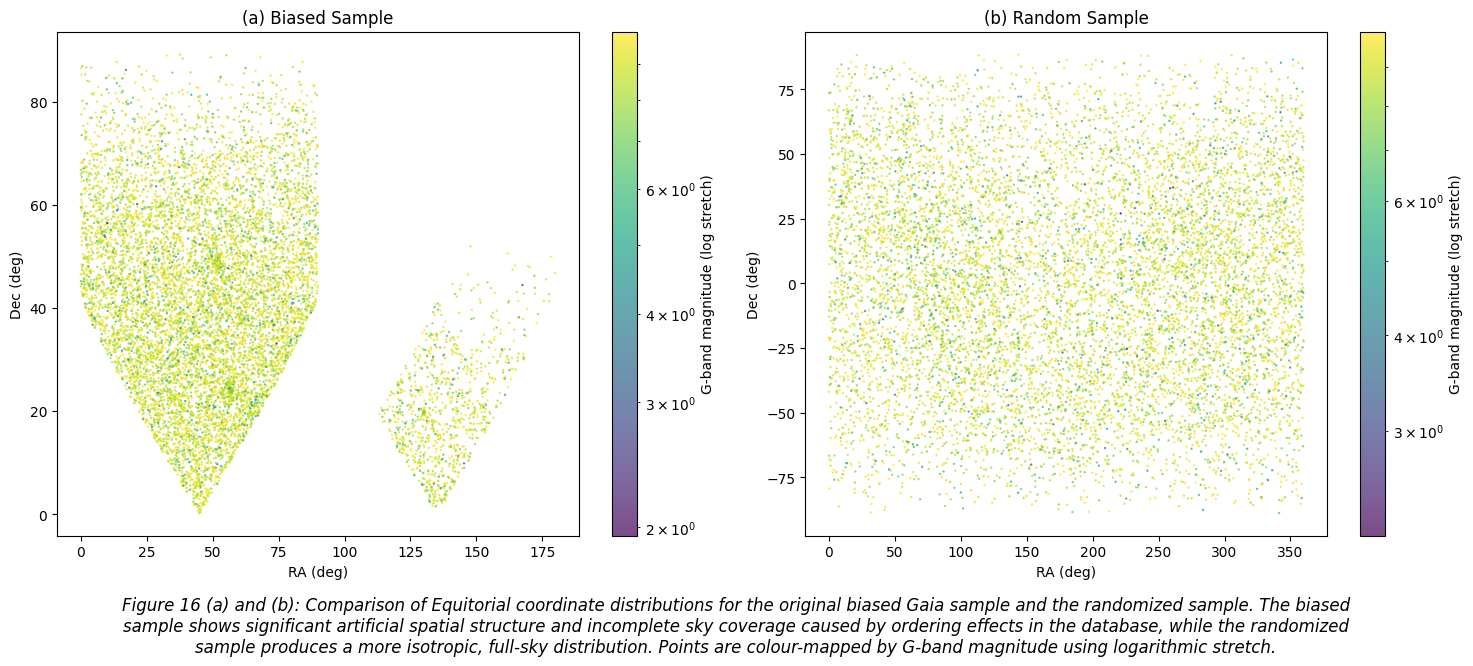

In [94]:
# RA/Dec scatter plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Biased
sc1 = ax1.scatter(biased['ra'], biased['dec'], c=biased['phot_g_mean_mag'], vmin=biased_g_min, vmax=biased_g_max, norm='log', cmap='viridis', s=0.5, alpha=0.7)
ax1.set_title('(a) Biased Sample')
ax1.set_xlabel(r'RA (deg)')
ax1.set_ylabel(r'Dec (deg)')
plt.colorbar(sc1, ax=ax1, label='G-band magnitude (log stretch)')


# Random
sc2 = ax2.scatter(random['ra'], random['dec'], c=random['phot_g_mean_mag'], vmin=random_g_min, vmax=random_g_max, norm='log', cmap='viridis', s=0.5, alpha=0.7)
ax2.set_title('(b) Random Sample')
ax2.set_xlabel('RA (deg)')
ax2.set_ylabel('Dec (deg)')
plt.colorbar(sc2, ax=ax2, label='G-band magnitude (log stretch)')

# Caption
fig_caption = r"""Figure 16 (a) and (b): Comparison of Equitorial coordinate distributions for the original biased Gaia sample and the randomized sample.
The biased sample shows significant artificial spatial structure and incomplete sky coverage caused by ordering effects in the database, while the randomized sample produces
a more isotropic, full-sky distribution. Points are colour-mapped by G-band magnitude using logarithmic stretch.
"""
wrapper = textwrap.TextWrapper(width=150)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
plt.figtext(1.3, -0.23, fig_caption_wrapped, transform=ax1.transAxes, ha='center', fontsize=12, style='italic')


plt.tight_layout()
plt.savefig("../../outputs/biased_and_random_ra_dec_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

#### 2.2. Aitoff Projections
In this section, we compare the positions of both biased and random samples in the Galactic coordinates.

First we need to wrap the galactic longitude (_l_) for both the biased and random sample in the interval [$-180^{\degree}$, $180^{\degree}$] ([-$\pi$, $\pi$] radians) and define the function for formatting longitude tick labels:

In [ ]:
from matplotlib.ticker import FuncFormatter


# Biased 
bias_l_wrapped = Longitude(biased['gal_l'], wrap_angle=180 * u.deg)
bias_l_rad = bias_l_wrapped.radian
bias_b_rad = Angle(biased['gal_b']).radian


# Random
rand_l_wrapped = Longitude(random['gal_l'], wrap_angle=180 * u.deg)
rand_l_rad = rand_l_wrapped.radian
rand_b_rad = Angle(random['gal_b']).radian


# Define format for longitude coordinate tickers
def coordinate_ticks(x, pos):
    """
    Determines the string value that get's displayed at each tick
    
    x: tick value (int, float)
    pos: tick position (automatic)
    
    Returns: coordinate tick value (string)
    """    
    tick_val = Angle(-x * u.radian).wrap_at(360 * u.deg).degree
    return f"${tick_val:.0f}" + r"^{\circ}$"


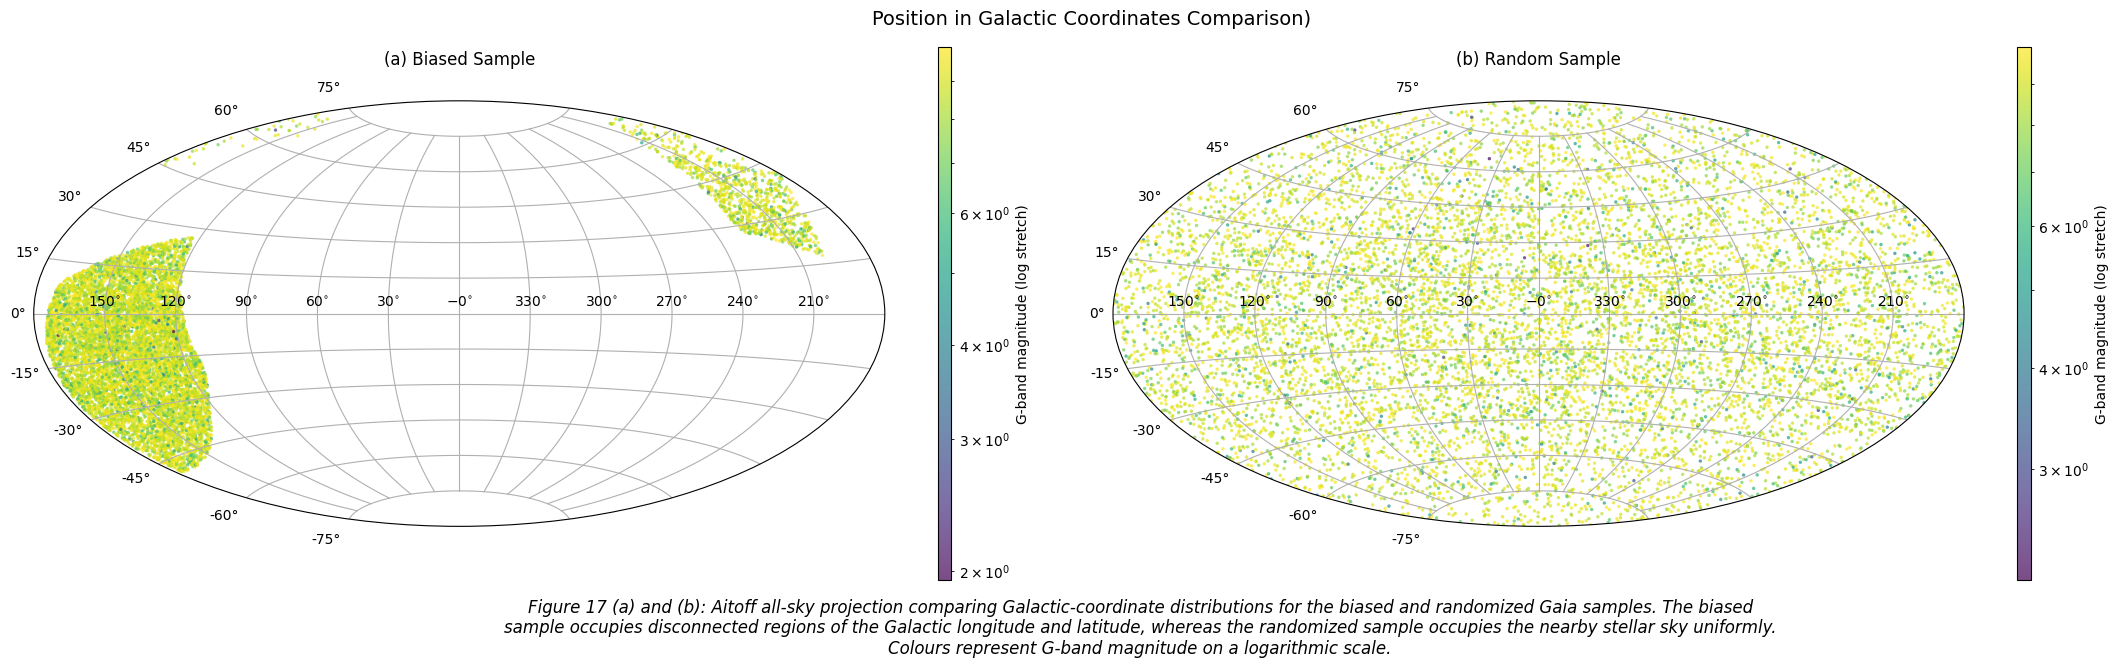

In [ ]:
# Aitoff Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 6), subplot_kw={'projection': 'aitoff'})

# Normalize using log stretch for magnitude color mapping
biased_norm = colors.LogNorm(vmin=biased_g_min, vmax=biased_g_max)
random_norm = colors.LogNorm(vmin=random_g_min, vmax=random_g_max)


# Biased
sc1 = ax1.scatter(-bias_l_rad, bias_b_rad, c=biased['phot_g_mean_mag'], norm=biased_norm, cmap='viridis', s=6, alpha=0.7, linewidths=0)
ax1.set_title("(a) Biased Sample", pad=26)
ax1.xaxis.set_major_formatter(FuncFormatter(coordinate_ticks))
ax1.grid(True)


# Random
sc2 = ax2.scatter(-rand_l_rad, rand_b_rad, c=random['phot_g_mean_mag'], norm=random_norm, cmap='viridis', s=6, alpha=0.7, linewidths=0)
ax2.set_title("(b) Random Sample", pad=26)
ax2.xaxis.set_major_formatter(FuncFormatter(coordinate_ticks))
ax2.grid(True)

# Colorbars for each plot
cbar1 = fig.colorbar(sc1, ax=ax1, location='right', pad=0.05, aspect=40)
cbar1.set_label('G-band magnitude (log stretch)')

cbar2 = fig.colorbar(sc2, ax=ax2, location='right', pad=0.05, aspect=40)
cbar2.set_label('G-band magnitude (log stretch)')

# Caption
fig_caption = r"""Figure 17 (a) and (b): Aitoff all-sky projection comparing Galactic-coordinate distributions for the biased and randomized Gaia samples. The biased sample occupies
disconnected regions of the Galactic longitude and latitude, whereas the randomized sample occupies the nearby stellar sky uniformly. Colours represent G-band magnitude on a
logarithmic scale.
"""
wrapper = textwrap.TextWrapper(width=150)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
plt.figtext(1.3, -0.3, fig_caption_wrapped, transform=ax1.transAxes, ha='center', fontsize=12, style='italic')

plt.suptitle("Position in Galactic Coordinates Comparison)", fontsize=14)
plt.tight_layout()
plt.savefig("../../outputs/biased_and_random_gal_coord_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

#### 2.3. Magnitude Histograms

Here we plot an overlaid histogram for both the biased and random sample apparent G-band magnitudes ($m_{G}$):

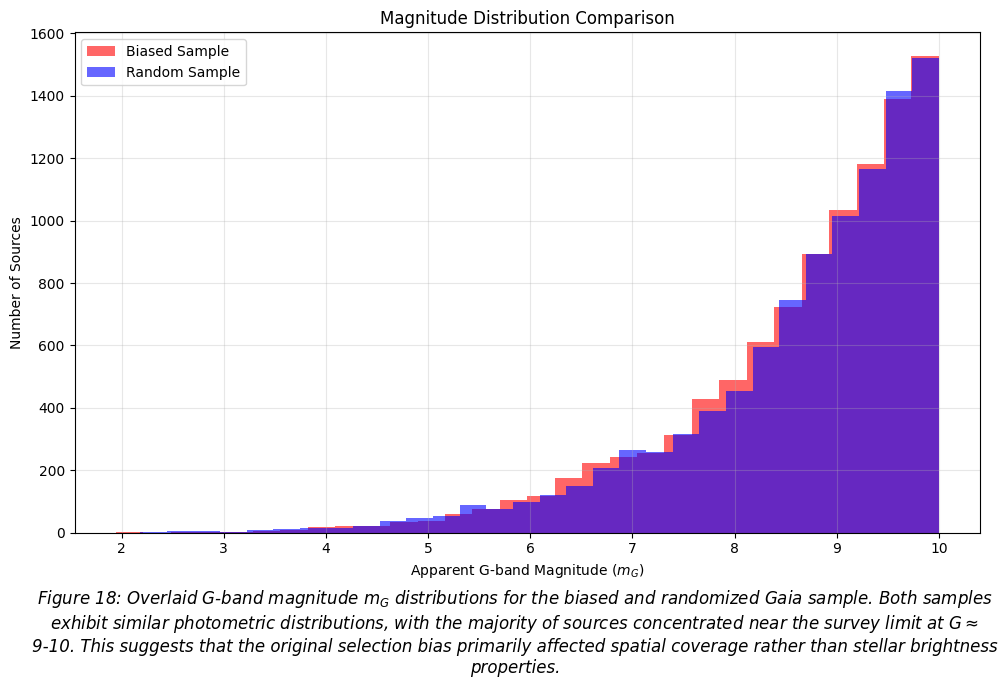

In [96]:
# Apparent magnitude histogram

plt.figure(figsize=(10, 6))
plt.hist(biased['phot_g_mean_mag'], bins=30, alpha=0.6, label='Biased Sample', color='red')
plt.hist(random['phot_g_mean_mag'], bins=30, alpha=0.6, label='Random Sample', color='blue')
plt.xlabel(r'Apparent G-band Magnitude ($m_{G}$)')
plt.ylabel('Number of Sources')
plt.title('Magnitude Distribution Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Caption
fig_caption = r"""Figure 18: Overlaid G-band magnitude $m_{G}$ distributions for the biased and randomized Gaia sample. Both samples exhibit similar photometric distributions, with the majority of
sources concentrated near the survey limit at G$\approx$ 9-10. This suggests that the original selection bias primarily affected spatial coverage rather than stellar brightness properties.
"""
wrapper = textwrap.TextWrapper(width=120)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
plt.figtext(0.52, -0.13
            , fig_caption_wrapped, ha='center', fontsize=12, style='italic')


plt.tight_layout()
plt.savefig("../../outputs/biased_and_random_app_mag_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

#### 2.4. Parallax Histograms

We now compare the distance distribution differences between the random and biased sample sources:

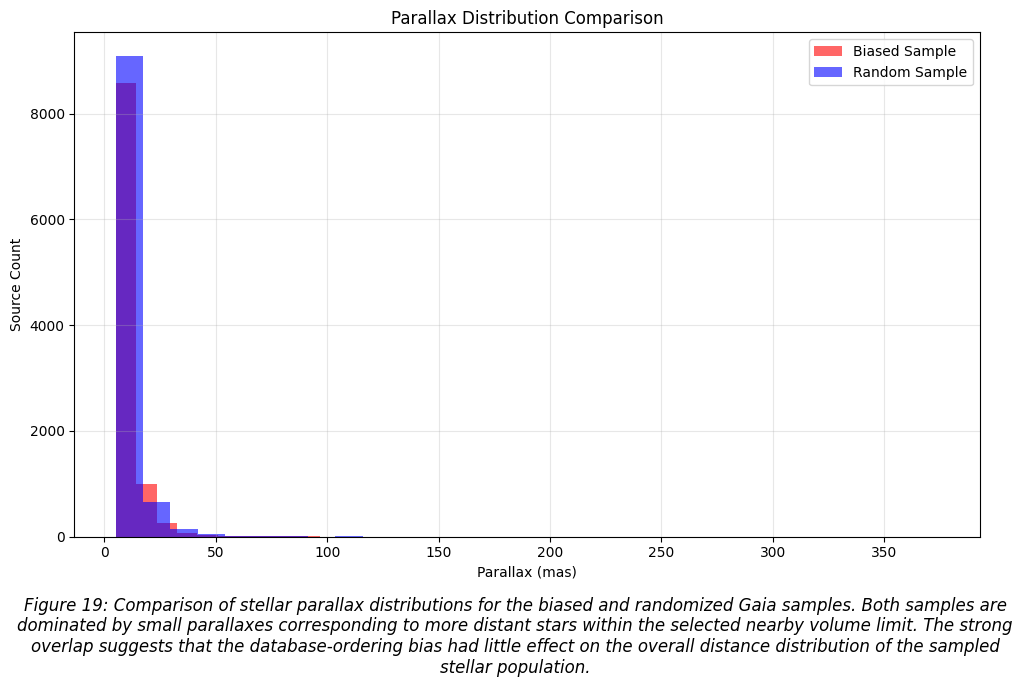

In [97]:
# Para;;ax histogram

plt.figure(figsize=(10, 6))
plt.hist(biased['parallax'], bins=30, alpha=0.6, label='Biased Sample', color='red')
plt.hist(random['parallax'], bins=30, alpha=0.6, label='Random Sample', color='blue')
plt.xlabel('Parallax (mas)')
plt.ylabel("Source Count")
plt.title('Parallax Distribution Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Caption
fig_caption = r"""Figure 19: Comparison of stellar parallax distributions for the biased and randomized Gaia samples. Both samples are dominated by small parallaxes corresponding to more
distant stars within the selected nearby volume limit. The strong overlap suggests that the database-ordering bias had little effect on the overall distance distribution of the sampled
stellar population.
"""
wrapper = textwrap.TextWrapper(width=120)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
plt.figtext(0.52, -0.13
            , fig_caption_wrapped, ha='center', fontsize=12, style='italic')


plt.tight_layout()
plt.savefig("../../outputs/biased_and_random_parallax_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

#### 2.5. BP-RP (`bp_rp`) Histograms

Now we compare colour-index distributions for both random and biased sample sources:

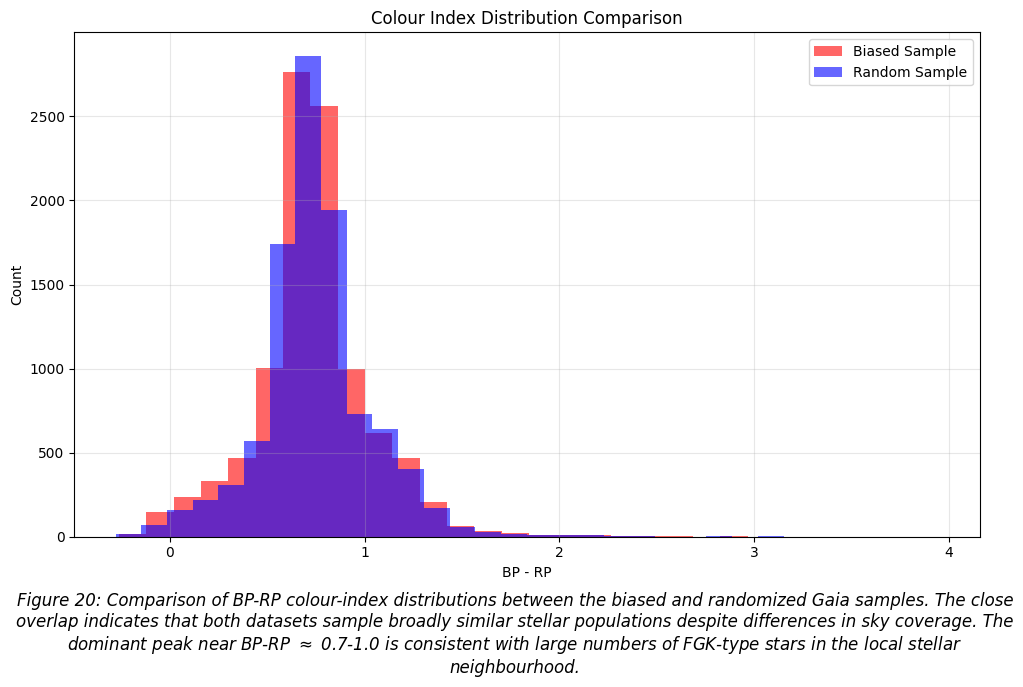

In [98]:
# Fill masked columns with NaN and drop

bp_rp_b_filled = biased['bp_rp'].filled(np.nan)
bp_rp_b_clean = bp_rp_b_filled[~np.isnan(bp_rp_b_filled)]
bp_rp_r_filled = random['bp_rp'].filled(np.nan)
bp_rp_r_clean = bp_rp_r_filled[~np.isnan(bp_rp_r_filled)]


# Colour-index histograms


plt.figure(figsize=(10, 6))
plt.hist(bp_rp_b_clean, bins=30, alpha=0.6, label='Biased Sample', color='red')
plt.hist(bp_rp_r_clean, bins=30, alpha=0.6, label='Random Sample', color='blue')
plt.xlabel('BP - RP')
plt.ylabel('Count')
plt.title('Colour Index Distribution Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Caption
fig_caption = r"""Figure 20: Comparison of BP-RP colour-index distributions between the biased and randomized Gaia samples. The close overlap indicates that both datasets sample broadly
similar stellar populations despite differences in sky coverage. The dominant peak near BP-RP $\approx$ 0.7-1.0 is consistent with large numbers of FGK-type stars in the local stellar
neighbourhood.
"""
wrapper = textwrap.TextWrapper(width=120)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
plt.figtext(0.52, -0.13
            , fig_caption_wrapped, ha='center', fontsize=12, style='italic')


plt.tight_layout()
plt.savefig("../../outputs/biased_and_random_colour_index_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

## Observation
- Comparison between the original and randomized Gaia samples revealed strong spatial-selection effects in the initial dataset. 
- The original sample displayed artificial geometric clustering and incomplete sky coverage in both the Equitorial and Galactic coordinate systems while the randomized sample produced a more isotropic sky distribution. 
- Despite the impact of biased and randomized sampling on spatial distribution, the magnitude, colour-index, and parallax distributions remained broadly consistent between the two samples. Therefore, bias in sampling affects only spatial coverage rather than underlying stellar population properties.